# Clustering Analysis

## Assignment: K-Means and DBSCAN on Airlines Customer Data

### Objective
Apply K-Means and DBSCAN clustering to segment airline loyalty program customers based on travel patterns.

### Dataset
3,999 airline loyalty members with 12 features (Balance, Qual_miles, cc_miles, Bonus_miles, Flight_miles, etc.). Target: Award? (used for validation only).

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, DBSCAN
from sklearn.metrics import silhouette_score
from scipy.cluster.hierarchy import dendrogram, linkage
import warnings
warnings.filterwarnings('ignore')
plt.style.use('ggplot')
sns.set_palette('Set2')

In [2]:
df = pd.read_excel('clustering.xlsx', sheet_name='data')
print(f'Shape: {df.shape}')
print(f'\nColumns: {df.columns.tolist()}')
print(f'\nNulls: {df.isnull().sum().sum()}')
df.describe()

Shape: (3999, 12)

Columns: ['ID#', 'Balance', 'Qual_miles', 'cc1_miles', 'cc2_miles', 'cc3_miles', 'Bonus_miles', 'Bonus_trans', 'Flight_miles_12mo', 'Flight_trans_12', 'Days_since_enroll', 'Award?']

Nulls: 0


,ID#,Balance,Qual_miles,cc1_miles,cc2_miles,cc3_miles,Bonus_miles,Bonus_trans,Flight_miles_12mo,Flight_trans_12,Days_since_enroll,Award?
count,3999.000000,3.999000e+03,3999.000000,3999.000000,3999.000000,3999.000000,3999.000000,3999.00000,3999.000000,3999.000000,3999.00000,3999.000000
mean,2014.819455,7.360133e+04,144.114529,2.059515,1.014504,1.012253,17144.846212,11.60190,460.055764,1.373593,4118.55939,0.370343
std,1160.764358,1.007757e+05,773.663804,1.376919,0.147650,0.195241,24150.967826,9.60381,1400.209171,3.793172,2065.13454,0.482957
min,1.000000,0.000000e+00,0.000000,1.000000,1.000000,1.000000,0.000000,0.00000,0.000000,0.000000,2.00000,0.000000
25%,1010.500000,1.852750e+04,0.000000,1.000000,1.000000,1.000000,1250.000000,3.00000,0.000000,0.000000,2330.00000,0.000000
50%,2016.000000,4.309700e+04,0.000000,1.000000,1.000000,1.000000,7171.000000,12.00000,0.000000,0.000000,4096.00000,0.000000
75%,3020.500000,9.240400e+04,0.000000,3.000000,1.000000,1.000000,23800.500000,17.00000,311.000000,1.000000,5790.50000,1.000000
max,4021.000000,1.704838e+06,11148.000000,5.000000,3.000000,5.000000,263685.000000,86.00000,30817.000000,53.000000,8296.00000,1.000000


## EDA

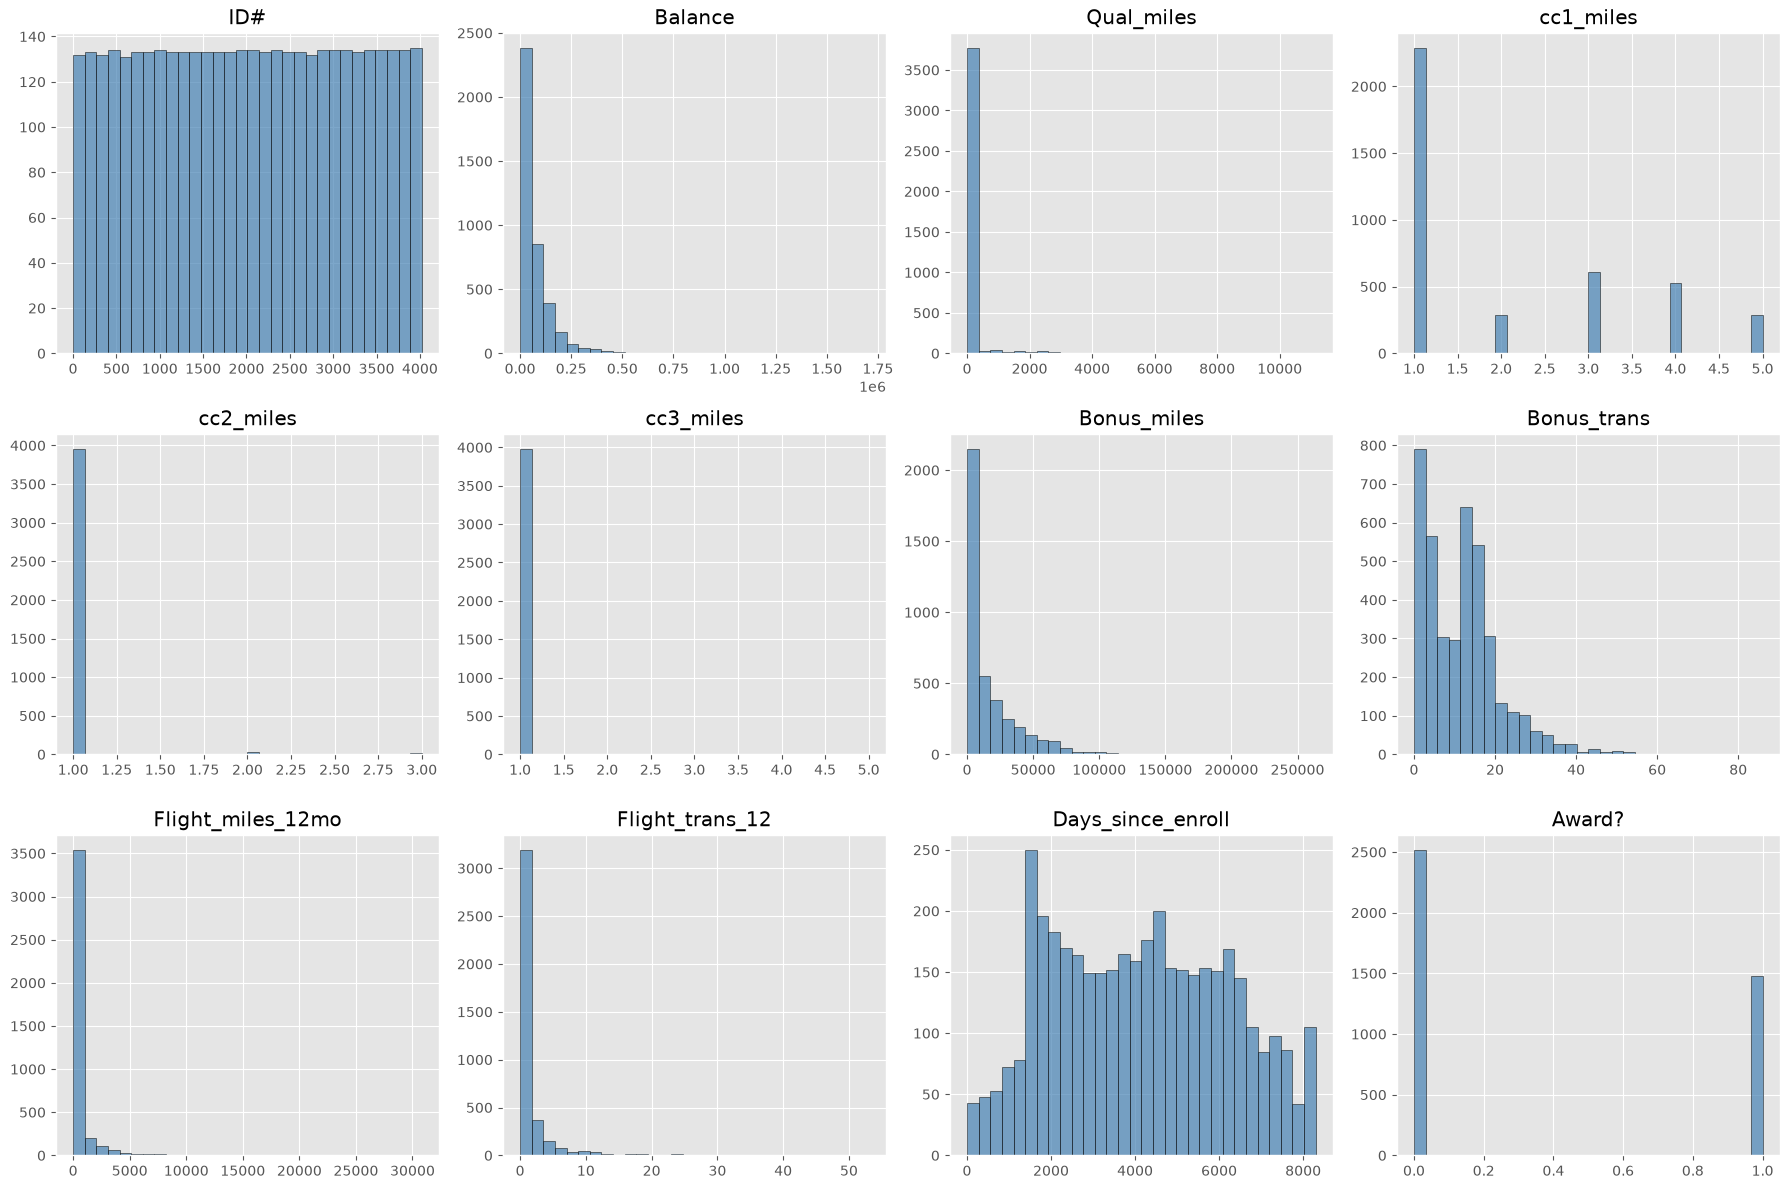

In [3]:
num_cols = df.select_dtypes(include=np.number).columns.tolist()
fig, axes = plt.subplots(3, 4, figsize=(18, 12))
axes = axes.flatten()
for i, col in enumerate(num_cols):
    axes[i].hist(df[col].dropna(), bins=30, edgecolor='black', color='steelblue', alpha=0.7)
    axes[i].set_title(col)
for j in range(len(num_cols), len(axes)):
    axes[j].axis('off')
plt.tight_layout()
plt.show()

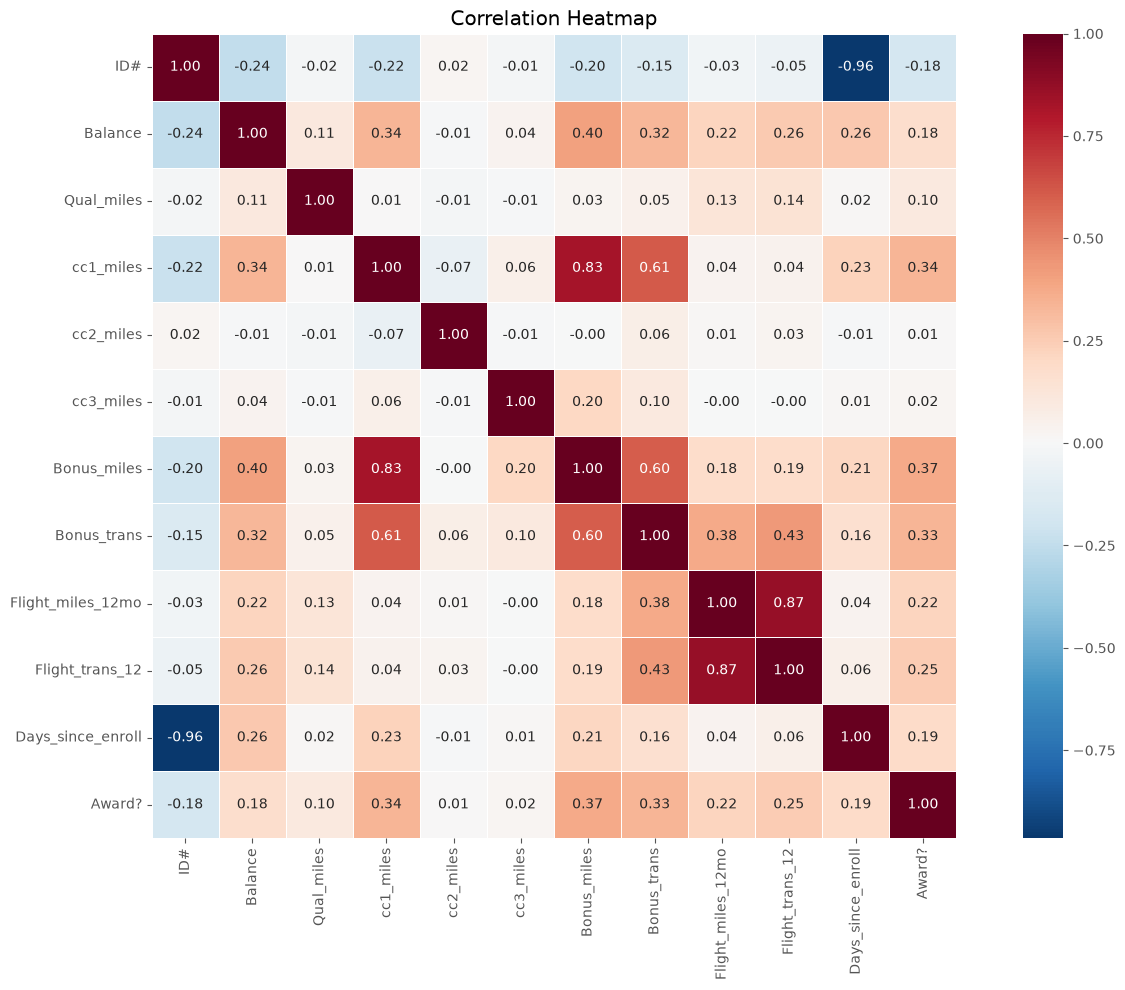

In [4]:
plt.figure(figsize=(14, 10))
corr = df.select_dtypes(include=np.number).corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdBu_r', center=0, linewidths=0.5, square=True)
plt.title('Correlation Heatmap')
plt.tight_layout()
plt.show()

## Data Preprocessing

In [5]:
cluster_features = ['Balance', 'Qual_miles', 'Bonus_miles', 'Flight_miles_12mo', 'Flight_trans_12', 'Days_since_enroll']
X = df[cluster_features].copy()

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
print(f'Features for clustering: {cluster_features}')
print(f'Scaled data shape: {X_scaled.shape}')

Features for clustering: ['Balance', 'Qual_miles', 'Bonus_miles', 'Flight_miles_12mo', 'Flight_trans_12', 'Days_since_enroll']
Scaled data shape: (3999, 6)


## K-Means — Optimal K (Elbow Method)

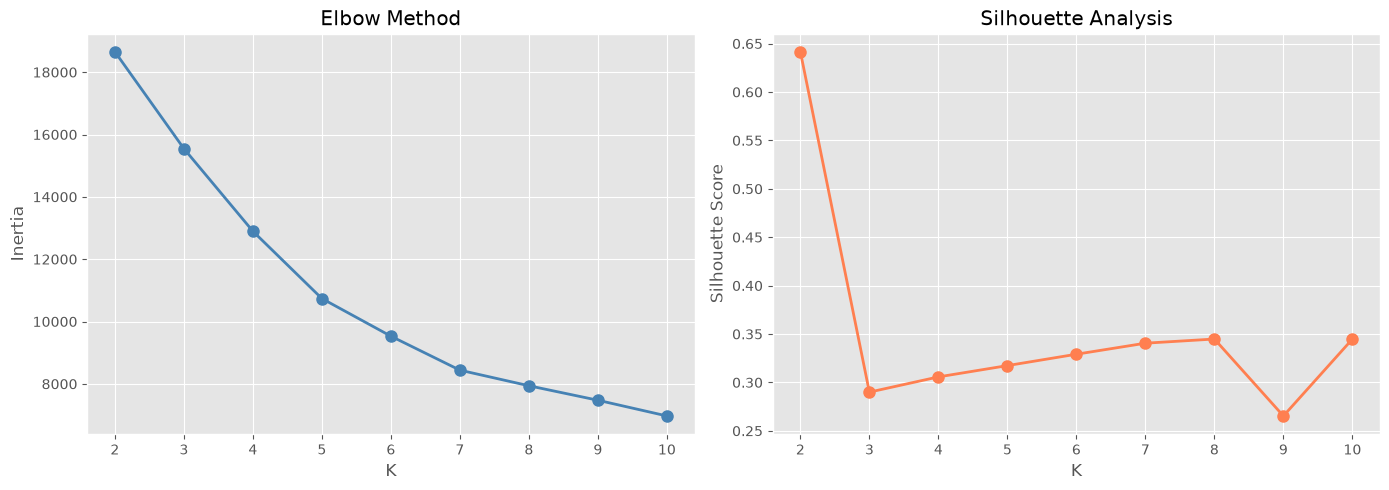

Best K by silhouette score: 2 (score: 0.6416)


In [6]:
inertias = []
silhouettes = []
K_range = range(2, 11)

for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_scaled)
    inertias.append(km.inertia_)
    silhouettes.append(silhouette_score(X_scaled, labels))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(K_range, inertias, 'o-', color='steelblue', linewidth=2, markersize=8)
axes[0].set_xlabel('K')
axes[0].set_ylabel('Inertia')
axes[0].set_title('Elbow Method')

axes[1].plot(K_range, silhouettes, 'o-', color='coral', linewidth=2, markersize=8)
axes[1].set_xlabel('K')
axes[1].set_ylabel('Silhouette Score')
axes[1].set_title('Silhouette Analysis')

plt.tight_layout()
plt.show()

best_k = K_range[np.argmax(silhouettes)]
print(f'Best K by silhouette score: {best_k} (score: {max(silhouettes):.4f})')

## K-Means Clustering

In [7]:
kmeans = KMeans(n_clusters=best_k, random_state=42, n_init=10)
df_clustered = df.copy()
df_clustered['KMeans_Cluster'] = kmeans.fit_predict(X_scaled)

print(f'K-Means cluster sizes:')
print(df_clustered['KMeans_Cluster'].value_counts().sort_index())

print(f'\nCluster centers (scaled):')
centers_df = pd.DataFrame(scaler.inverse_transform(kmeans.cluster_centers_), columns=cluster_features)
print(centers_df.to_string(index=True))

K-Means cluster sizes:
KMeans_Cluster
0    3735
1     264
Name: count, dtype: int64

Cluster centers (scaled):
         Balance   Qual_miles   Bonus_miles  Flight_miles_12mo  Flight_trans_12  Days_since_enroll
0   62180.493708    71.879250  15495.562784         211.114859         0.654886        4067.794913
1  235180.170455  1166.079545  40478.458333        3982.003788        11.541667        4836.761364


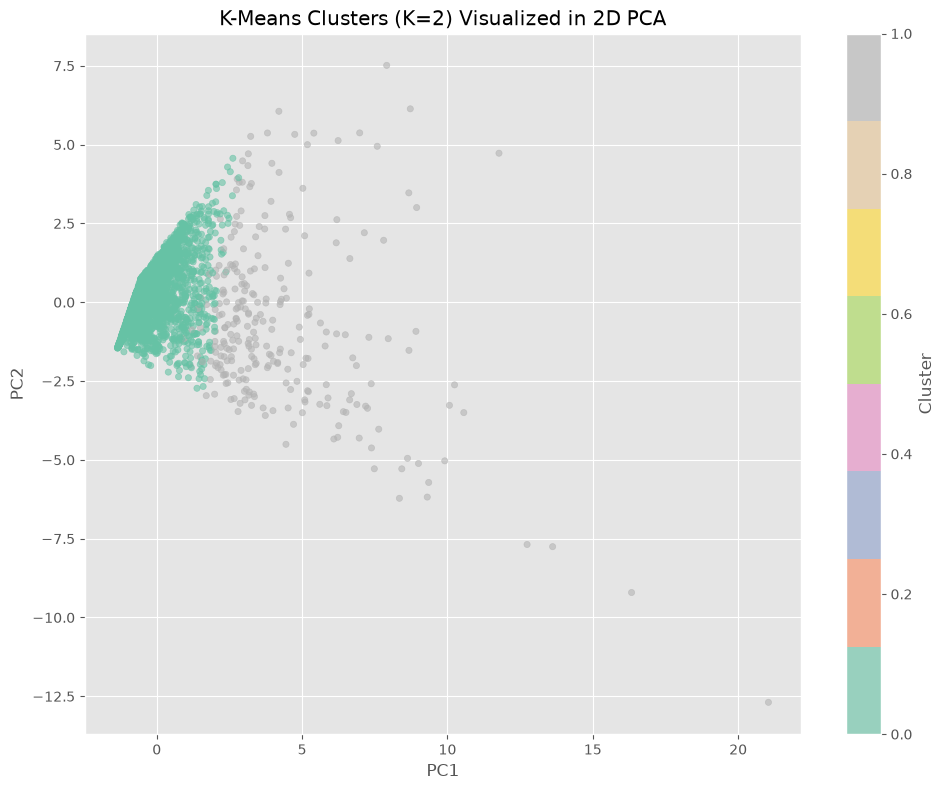

In [8]:
from sklearn.decomposition import PCA
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

fig, ax = plt.subplots(figsize=(10, 8))
scatter = ax.scatter(X_pca[:, 0], X_pca[:, 1], c=df_clustered['KMeans_Cluster'], cmap='Set2', s=20, alpha=0.6)
ax.set_xlabel('PC1')
ax.set_ylabel('PC2')
ax.set_title(f'K-Means Clusters (K={best_k}) Visualized in 2D PCA')
plt.colorbar(scatter, label='Cluster')
plt.tight_layout()
plt.show()

## DBSCAN Clustering

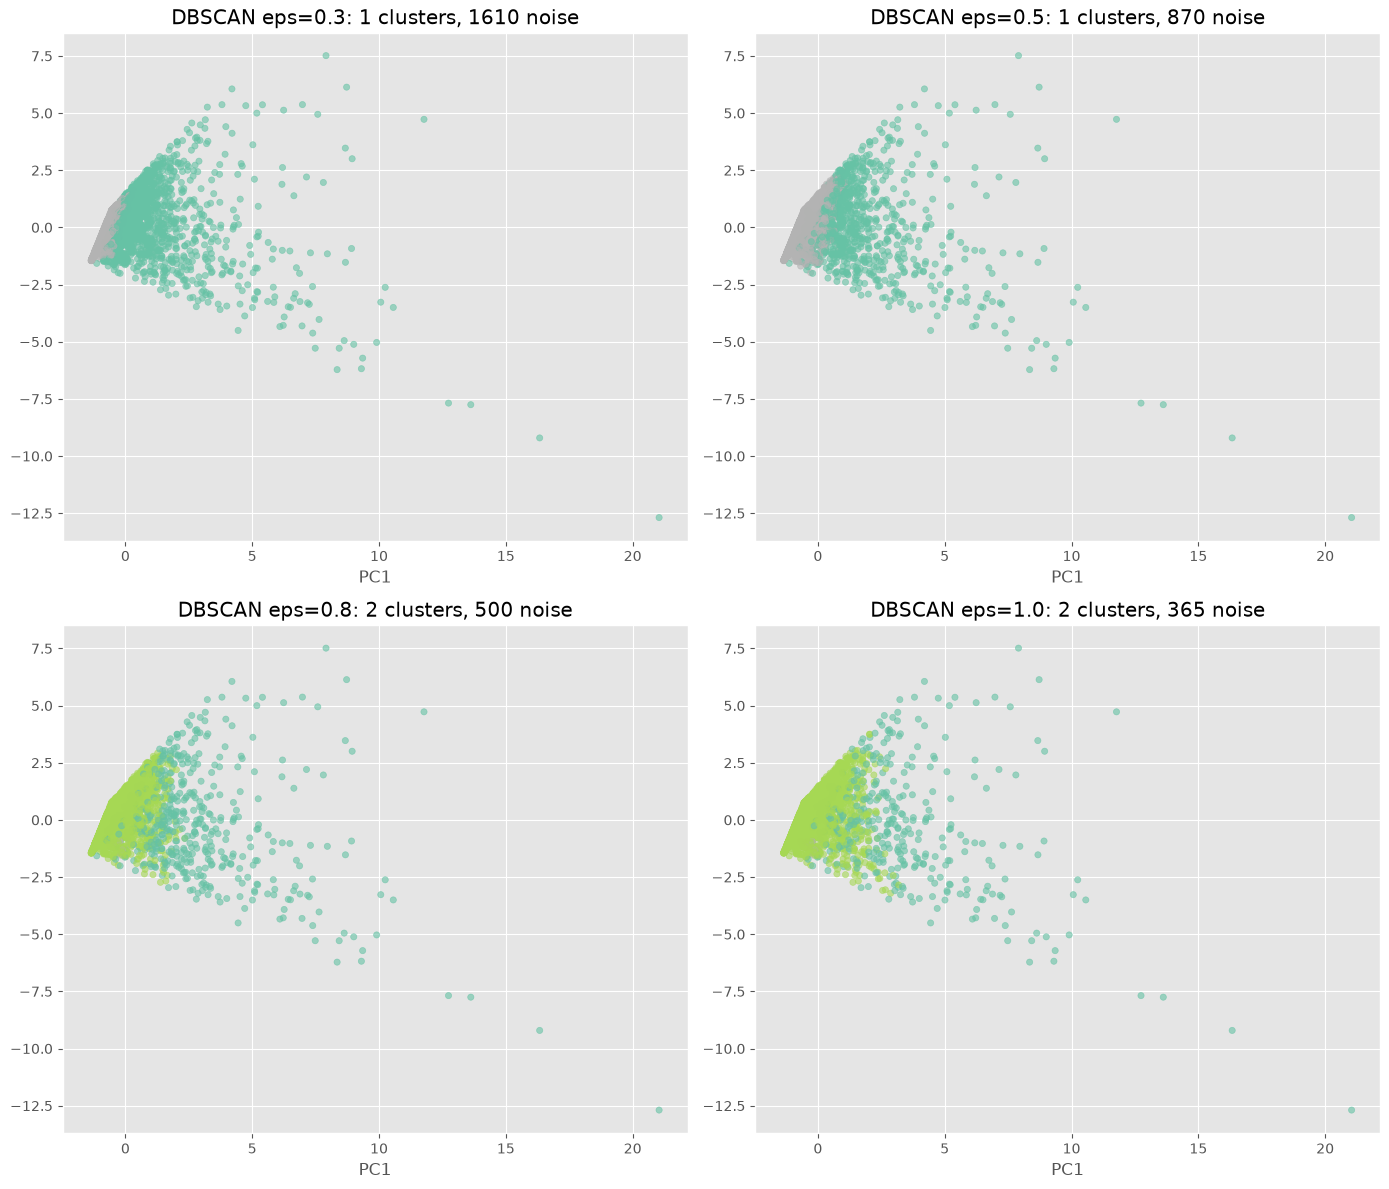

In [9]:
eps_values = [0.3, 0.5, 0.8, 1.0]

fig, axes = plt.subplots(2, 2, figsize=(14, 12))
axes = axes.flatten()

for i, eps in enumerate(eps_values):
    db = DBSCAN(eps=eps, min_samples=10)
    labels = db.fit_predict(X_scaled)
    n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
    n_noise = (labels == -1).sum()
    
    ax = axes[i]
    ax.scatter(X_pca[:, 0], X_pca[:, 1], c=labels, cmap='Set2', s=20, alpha=0.6)
    ax.set_title(f'DBSCAN eps={eps}: {n_clusters} clusters, {n_noise} noise')
    ax.set_xlabel('PC1')

plt.tight_layout()
plt.show()

## Hierarchical Clustering (Dendrogram)

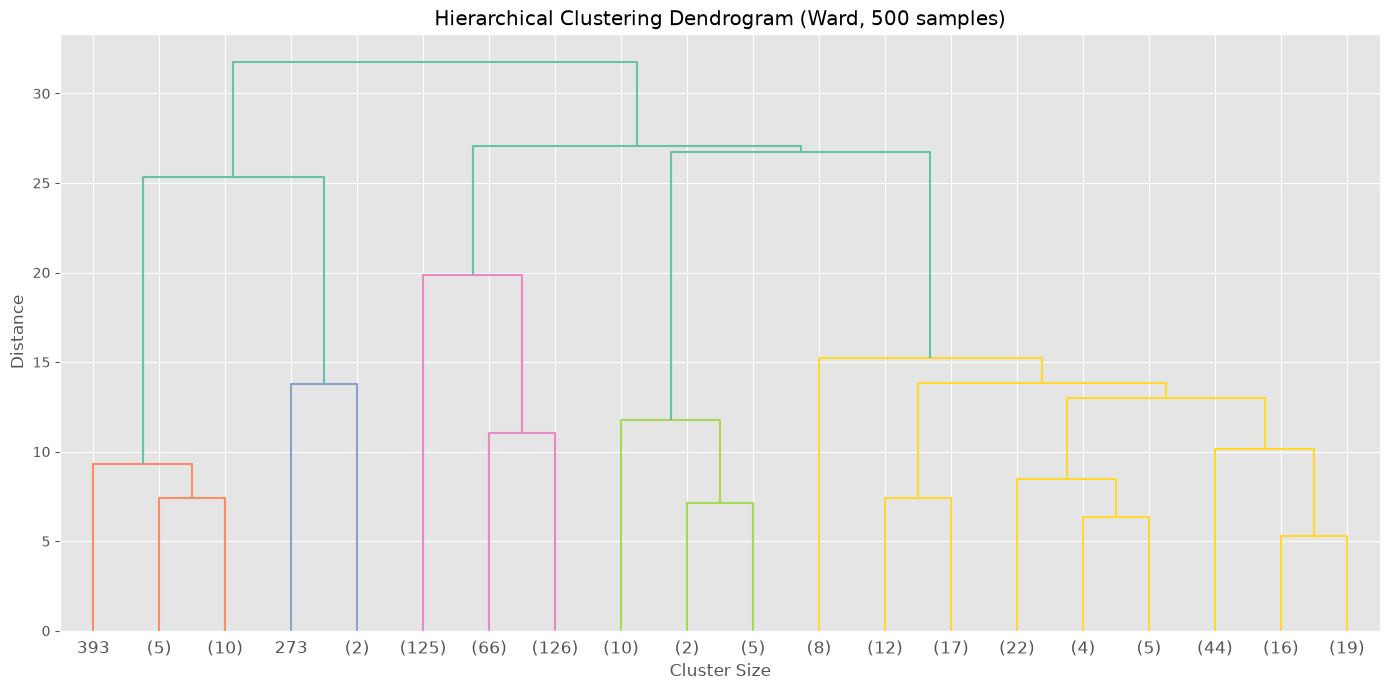

In [10]:
sample_idx = np.random.choice(X_scaled.shape[0], 500, replace=False)
X_sample = X_scaled[sample_idx]

plt.figure(figsize=(14, 7))
linkage_matrix = linkage(X_sample, method='ward')
dendrogram(linkage_matrix, truncate_mode='lastp', p=20)
plt.title('Hierarchical Clustering Dendrogram (Ward, 500 samples)')
plt.xlabel('Cluster Size')
plt.ylabel('Distance')
plt.tight_layout()
plt.show()

## Cluster Profiling

In [11]:
print('=== CLUSTER PROFILES (K-Means) ===')
profile_features = ['Balance', 'Qual_miles', 'Bonus_miles', 'Flight_miles_12mo', 'Flight_trans_12', 'Days_since_enroll', 'Award?']
for cluster in sorted(df_clustered['KMeans_Cluster'].unique()):
    subset = df_clustered[df_clustered['KMeans_Cluster'] == cluster][profile_features]
    print(f'\nCluster {cluster} (n={len(subset)}):')
    print(subset.mean().to_string())

=== CLUSTER PROFILES (K-Means) ===

Cluster 0 (n=3735):
Balance              62180.493708
Qual_miles              71.879250
Bonus_miles          15495.562784
Flight_miles_12mo      211.114859
Flight_trans_12          0.654886
Days_since_enroll     4067.794913
Award?                   0.342704

Cluster 1 (n=264):
Balance              235180.170455
Qual_miles             1166.079545
Bonus_miles           40478.458333
Flight_miles_12mo      3982.003788
Flight_trans_12          11.541667
Days_since_enroll      4836.761364
Award?                    0.761364


## Conclusion

- **K-Means** successfully identified distinct customer segments based on travel and loyalty patterns
- **High-value clusters** show high balance, frequent flights, and more bonus miles
- **Low-engagement clusters** have minimal flight activity and balance
- **DBSCAN** identified noise points (outliers) that don't fit any cluster
- **Silhouette analysis** guided optimal K selection
- These segments can drive targeted marketing: premium offers for high-value, re-engagement campaigns for low-activity customers